# Strong Gravitational Lens Parameter Inference -- Full Pipeline

This notebook runs the whole project end to end and is the place to **experiment**:
simulate lenses, look at the dataset, train the BayesFlow posterior approximator, and
evaluate how well it recovers the lens parameters. It is written to run on a laptop
**CPU only** (no GPU/CUDA needed) -- everything is sized to fit comfortably in RAM on
a machine with a small/no dedicated GPU (this project targets a 4GB-VRAM laptop by
simply never using the GPU at all: the Keras backend is `torch` running on CPU).

**How to run this notebook**: use the project's own virtual environment as the Jupyter
kernel (`strong-lens-inference/.venv`), not your system Python. From a terminal in the
project root, with the venv activated:
```
python -m ipykernel install --user --name=strong-lens-inference --display-name "strong-lens-inference (.venv)"
jupyter notebook notebooks/run_pipeline.ipynb
```
then pick the "strong-lens-inference (.venv)" kernel. Run the cells top to bottom the
first time; after that, re-run only the sections you're experimenting with.

## What each section does
1. Setup -- imports, sanity-check the environment.
2. Look at every tunable knob in `src/config.py`.
3. Simulator demo -- draw a few random lenses and look at them (fast, no dataset needed).
4. Generate the training/validation/test dataset (the slow, CPU-bound step).
5. Inspect the generated dataset.
6. Build the networks and train the BayesFlow approximator.
7. Evaluate: parameter recovery, calibration, posterior predictive checks.
8. The kappa (external convergence) / mass-sheet-degeneracy comparison the assignment asks about.
9. Cheat-sheet: every parameter you can change, where it lives, and what changing it does.

> If you only remember one thing: **every tunable number lives in `src/config.py`.**
> This notebook mostly just calls functions from `src/` and shows you the results;
> read the comments inside those files (especially `src/config.py`) for the "why"
> behind each default.

## 1. Setup

In [1]:
import os
import sys

# Make the project root importable (this notebook lives in notebooks/, one level
# below the project root, so `src` is not on sys.path by default).
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)  # so relative paths (data/, figures/) match the CLI scripts

# IMPORTANT: the Keras backend must be selected before keras/bayesflow are
# imported anywhere in this process. src/config.py's KERAS_BACKEND (default
# "torch") is the single source of truth for this -- see its comments for why.
from src import config as C
os.environ.setdefault("KERAS_BACKEND", C.KERAS_BACKEND)

import numpy as np
import matplotlib.pyplot as plt
import keras

%matplotlib inline

print("Keras backend:", keras.backend.backend())
print("CPU cores available for dataset generation (config.N_WORKERS):", C.N_WORKERS)

Keras backend: torch
CPU cores available for dataset generation (config.N_WORKERS): 11


## 2. Every tunable knob, at a glance

Everything below is read straight from `src/config.py`. Change a value there (and
re-run this cell / restart the kernel for values that affect array shapes, see the
warning in `config.py` next to `INCLUDE_KAPPA`), then re-run the later sections to see
the effect.

In [2]:
print("theta = ", C.PARAM_NAMES, f"({C.NUM_PARAMS} parameters, INCLUDE_KAPPA={C.INCLUDE_KAPPA})")
print()
print("Prior ranges p(theta):")
for k, v in C.PRIOR.items():
    print(f"  {k:>10}: {v}")
print()
print(f"Image grid   : {C.NUM_PIX}x{C.NUM_PIX} px, {C.DELTA_PIX}\"/px -> {C.NUM_PIX*C.DELTA_PIX:.2f}\" field of view")
print(f"PSF FWHM     : {C.PSF_FWHM}\"")
print(f"Noise        : background_rms={C.BACKGROUND_RMS}, exp_time={C.EXP_TIME}, source_amp={C.SOURCE_AMP}")
print(f"Dataset sizes: N_TRAIN={C.N_TRAIN}, N_VAL={C.N_VAL}, N_TEST={C.N_TEST}")
print(f"Network      : SUMMARY_DIM={C.SUMMARY_DIM}, COUPLING_DEPTH={C.COUPLING_DEPTH}")
print(f"Training     : EPOCHS={C.EPOCHS}, BATCH_SIZE={C.BATCH_SIZE}, LEARNING_RATE={C.LEARNING_RATE}")

theta =  ['theta_E', 'e1', 'e2', 'gamma1', 'gamma2', 'x_s', 'y_s', 'R_s'] (8 parameters, INCLUDE_KAPPA=False)

Prior ranges p(theta):
     theta_E: (0.7, 1.6)
           q: (0.6, 1.0)
         phi: (0.0, 3.14159265)
   gamma_ext: (0.0, 0.08)
     phi_ext: (0.0, 3.14159265)
         x_s: (-0.3, 0.3)
         y_s: (-0.3, 0.3)
         R_s: (0.05, 0.25)
       kappa: (0.0, 0.2)

Image grid   : 64x64 px, 0.05"/px -> 3.20" field of view
PSF FWHM     : 0.1"
Noise        : background_rms=0.1, exp_time=100.0, source_amp=20.0
Dataset sizes: N_TRAIN=8000, N_VAL=1000, N_TEST=300
Network      : SUMMARY_DIM=48, COUPLING_DEPTH=4
Training     : EPOCHS=40, BATCH_SIZE=32, LEARNING_RATE=0.001


## 3. Simulator demo (fast -- no dataset needed)

Draws a handful of `theta ~ p(theta)` and runs the forward model. Use this cell after
any change to `src/config.py` or the simulator code to sanity-check that images still
look like plausible lenses (a ring/arc, not noise or a blank frame) before spending
minutes regenerating the whole dataset.

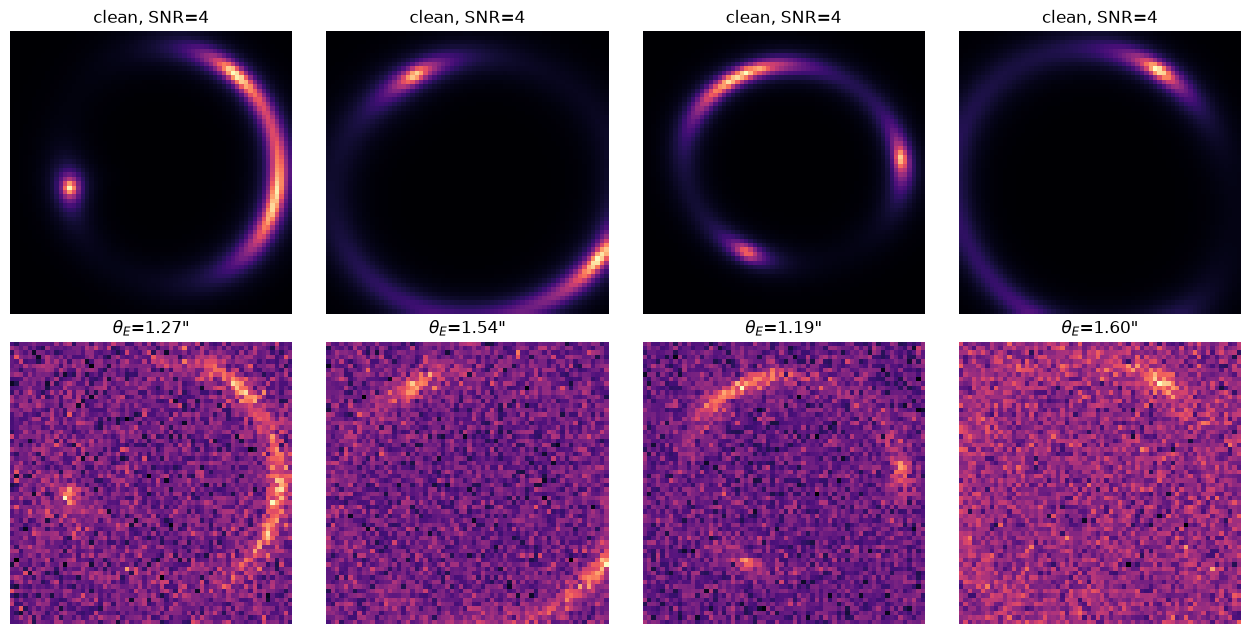

In [3]:
from src.simulator.lens_generator import simulate_random_lens
from src.simulator.noise import add_noise, peak_snr

rng = np.random.default_rng(0)
n_demo = 4
fig, axes = plt.subplots(2, n_demo, figsize=(3.2 * n_demo, 6.4))
for i in range(n_demo):
    theta, clean = simulate_random_lens(rng)
    noisy = add_noise(clean, rng=rng)
    axes[0, i].imshow(clean, origin="lower", cmap="magma")
    axes[0, i].set_title(f"clean, SNR={peak_snr(clean):.0f}")
    axes[0, i].axis("off")
    axes[1, i].imshow(noisy, origin="lower", cmap="magma")
    axes[1, i].set_title(r"$\theta_E$=" + f"{theta['theta_E']:.2f}\"")
    axes[1, i].axis("off")
fig.tight_layout()
plt.show()

peak SNR over 60 random draws: min=1.4  median=3.8  max=5.9


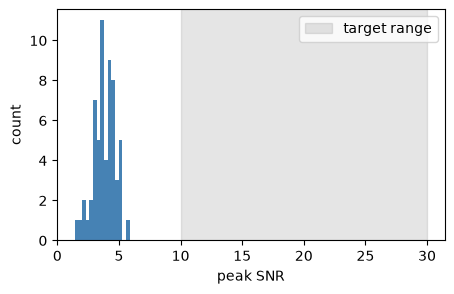

In [4]:
# Peak-SNR distribution over many random draws. The assignment targets a realistic
# peak SNR of roughly 10-30. If the median below is far outside that range, tune
# config.SOURCE_AMP (brighter source -> higher SNR) or config.BACKGROUND_RMS
# (more sky noise -> lower SNR) in src/config.py and re-run this cell.
from src.simulator.lens_generator import simulate_clean
from src.simulator.parameters import sample_prior

snrs = [peak_snr(simulate_clean(sample_prior(rng))) for _ in range(60)]
print(f"peak SNR over 60 random draws: min={min(snrs):.1f}  median={np.median(snrs):.1f}  max={max(snrs):.1f}")
plt.figure(figsize=(5, 3))
plt.hist(snrs, bins=15, color="steelblue")
plt.axvspan(10, 30, color="grey", alpha=0.2, label="target range")
plt.xlabel("peak SNR"); plt.ylabel("count"); plt.legend(); plt.show()

## 4. Generate the dataset

This is the slow, CPU-bound step (lenstronomy has no GPU path) -- precomputing once and
training on the saved arrays afterwards is exactly what makes the rest of the pipeline
fast and repeatable. With the default sizes (`config.N_TRAIN=8000`, `N_VAL=1000`,
`N_TEST=300`) and multiprocessing across `config.N_WORKERS` CPU cores, this typically
takes a few minutes on a modern laptop. **First time through, consider shrinking the
sizes** (uncomment the block below) to get the whole notebook running end to end in
under a minute, then come back and re-run with the full sizes for a real model.

In [5]:
# --- OPTIONAL: shrink the dataset for a quick first pass through the notebook ---
# C.N_TRAIN, C.N_VAL, C.N_TEST = 1500, 300, 150
# C.EPOCHS = 15
# ---------------------------------------------------------------------------------

from src.simulator.dataset import build_and_save

build_and_save()

Generating TRAIN (8000) + VAL (1000) using 11 worker(s) ...
     500/8000  ( 43.2 sims/s, 11 workers)
    1000/8000  ( 86.2 sims/s, 11 workers)
    1500/8000  (126.7 sims/s, 11 workers)
    2000/8000  (164.2 sims/s, 11 workers)
    2500/8000  (202.9 sims/s, 11 workers)
    3000/8000  (240.2 sims/s, 11 workers)
    3500/8000  (276.1 sims/s, 11 workers)
    4000/8000  (311.9 sims/s, 11 workers)
    4500/8000  (339.5 sims/s, 11 workers)
    5000/8000  (372.7 sims/s, 11 workers)
    5500/8000  (405.2 sims/s, 11 workers)
    6000/8000  (436.6 sims/s, 11 workers)
    6500/8000  (465.7 sims/s, 11 workers)
    7000/8000  (495.0 sims/s, 11 workers)
    7500/8000  (523.8 sims/s, 11 workers)
    8000/8000  (553.3 sims/s, 11 workers)

  --- peak-SNR report (tune config.SOURCE_AMP / BACKGROUND_RMS) ---
    min=  0.8  median=  3.7  max=  7.5   target ~ 10-30

     500/1000  ( 39.7 sims/s, 11 workers)
    1000/1000  ( 79.4 sims/s, 11 workers)
Saved data\processed\lens_dataset.npz

Generating TEST (30

## 5. Inspect the generated dataset

In [6]:
from src.evaluation import plots

d = np.load(os.path.join(C.DATA_DIR, C.DATA_FILE))
print("train images:", d["images_train"].shape, " theta:", d["theta_train"].shape)
plots.plot_dataset_preview(d["images_train"], d["theta_train"], num_to_display=4)
plt.show()

train images: (8000, 64, 64, 1)  theta: (8000, 8)
saved figures\dataset_preview.png


## 6. Build the networks and train

`train.main()` loads the saved dataset, builds the CNN summary network + coupling-flow
inference network (`src/models/bayesflow_model.py`), trains, and saves the approximator
to `data/models/`. It returns the live `workflow` object so we can evaluate immediately
without reloading from disk -- the most reliable way to run evaluation right after
training in BayesFlow.

In [7]:
from src.models.train import main as train_main

workflow, history = train_main()

INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).


Keras backend: torch
Loading offline data ...


INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


  train images: (8000, 64, 64, 1), val images: (1000, 64, 64, 1), params: ['theta_E', 'e1', 'e2', 'gamma1', 'gamma2', 'x_s', 'y_s', 'R_s']
Training for 40 epochs (batch_size=32) ...
Epoch 1/40
250/250 - 129s - 516ms/step - loss: 10.6684 - val_loss: 1472.3124
Epoch 2/40
250/250 - 127s - 508ms/step - loss: 9.6457 - val_loss: 86.6012
Epoch 3/40
250/250 - 126s - 504ms/step - loss: 8.0954 - val_loss: 8.4419
Epoch 4/40
250/250 - 129s - 515ms/step - loss: 7.1663 - val_loss: 10.6036
Epoch 5/40
250/250 - 125s - 500ms/step - loss: 6.6068 - val_loss: 7.3571
Epoch 6/40
250/250 - 125s - 500ms/step - loss: 6.0770 - val_loss: 8.1781
Epoch 7/40
250/250 - 126s - 506ms/step - loss: 5.7552 - val_loss: 7.2423
Epoch 8/40
250/250 - 126s - 503ms/step - loss: 5.4974 - val_loss: 8.1197
Epoch 9/40
250/250 - 126s - 504ms/step - loss: 5.1580 - val_loss: 5.2119
Epoch 10/40
250/250 - 127s - 506ms/step - loss: 4.7948 - val_loss: 5.8225
Epoch 11/40
250/250 - 128s - 512ms/step - loss: 4.6131 - val_loss: 5.8759
Epoch 1

INFO:bayesflow:Training completed in 1.36 hours.


Saved trained approximator -> data\models\lens_approximator.keras


In [8]:
plots.plot_training_history(history)
plt.show()

saved figures\training_loss.png


## 7. Evaluate

Three standard simulation-based-inference diagnostics, computed on the held-out test set:

1. **Parameter recovery** -- posterior mean vs. true value, one panel per parameter.
   Points on the diagonal = accurate recovery; a flat cloud = that parameter is barely
   constrained by the image.
2. **Calibration (SBC)** -- is the posterior's *uncertainty* trustworthy, not just its
   mean? A flat rank histogram (within the grey band) means yes.
3. **Posterior predictive** -- re-simulate a few posterior draws for one held-out image
   and compare them by eye to the observation.

In [9]:
from src.evaluation.test import run_all

run_all(workflow, num_samples=2000)

Sampling posteriors for the held-out test set ...


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 8.92 seconds.


Diagnostics:
saved figures\recovery.png
saved figures\calibration.png (flat within the grey band = well calibrated)
saved figures\posterior_predictive.png
  kappa not in the model (INCLUDE_KAPPA=False in config.py) -- nothing to analyze. Flip INCLUDE_KAPPA to True, re-run `generate` + `train`, and call this again to see the mass-sheet degeneracy.


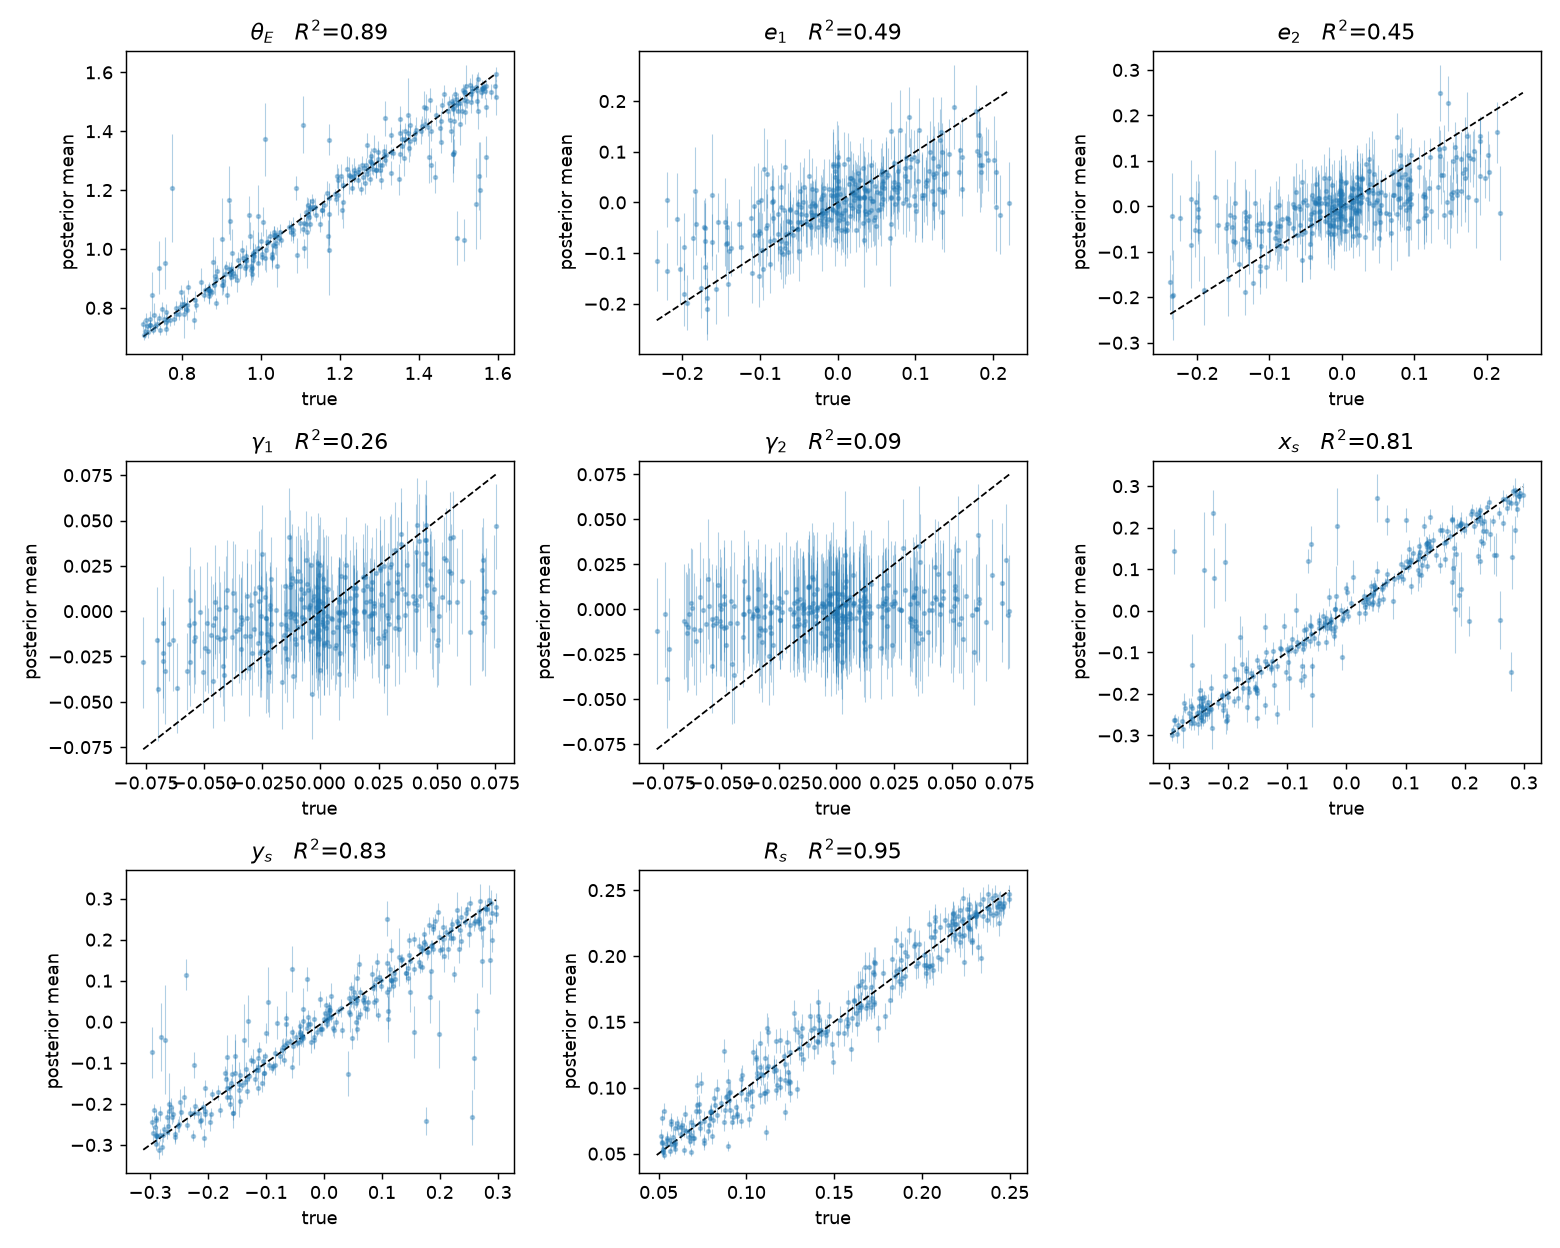

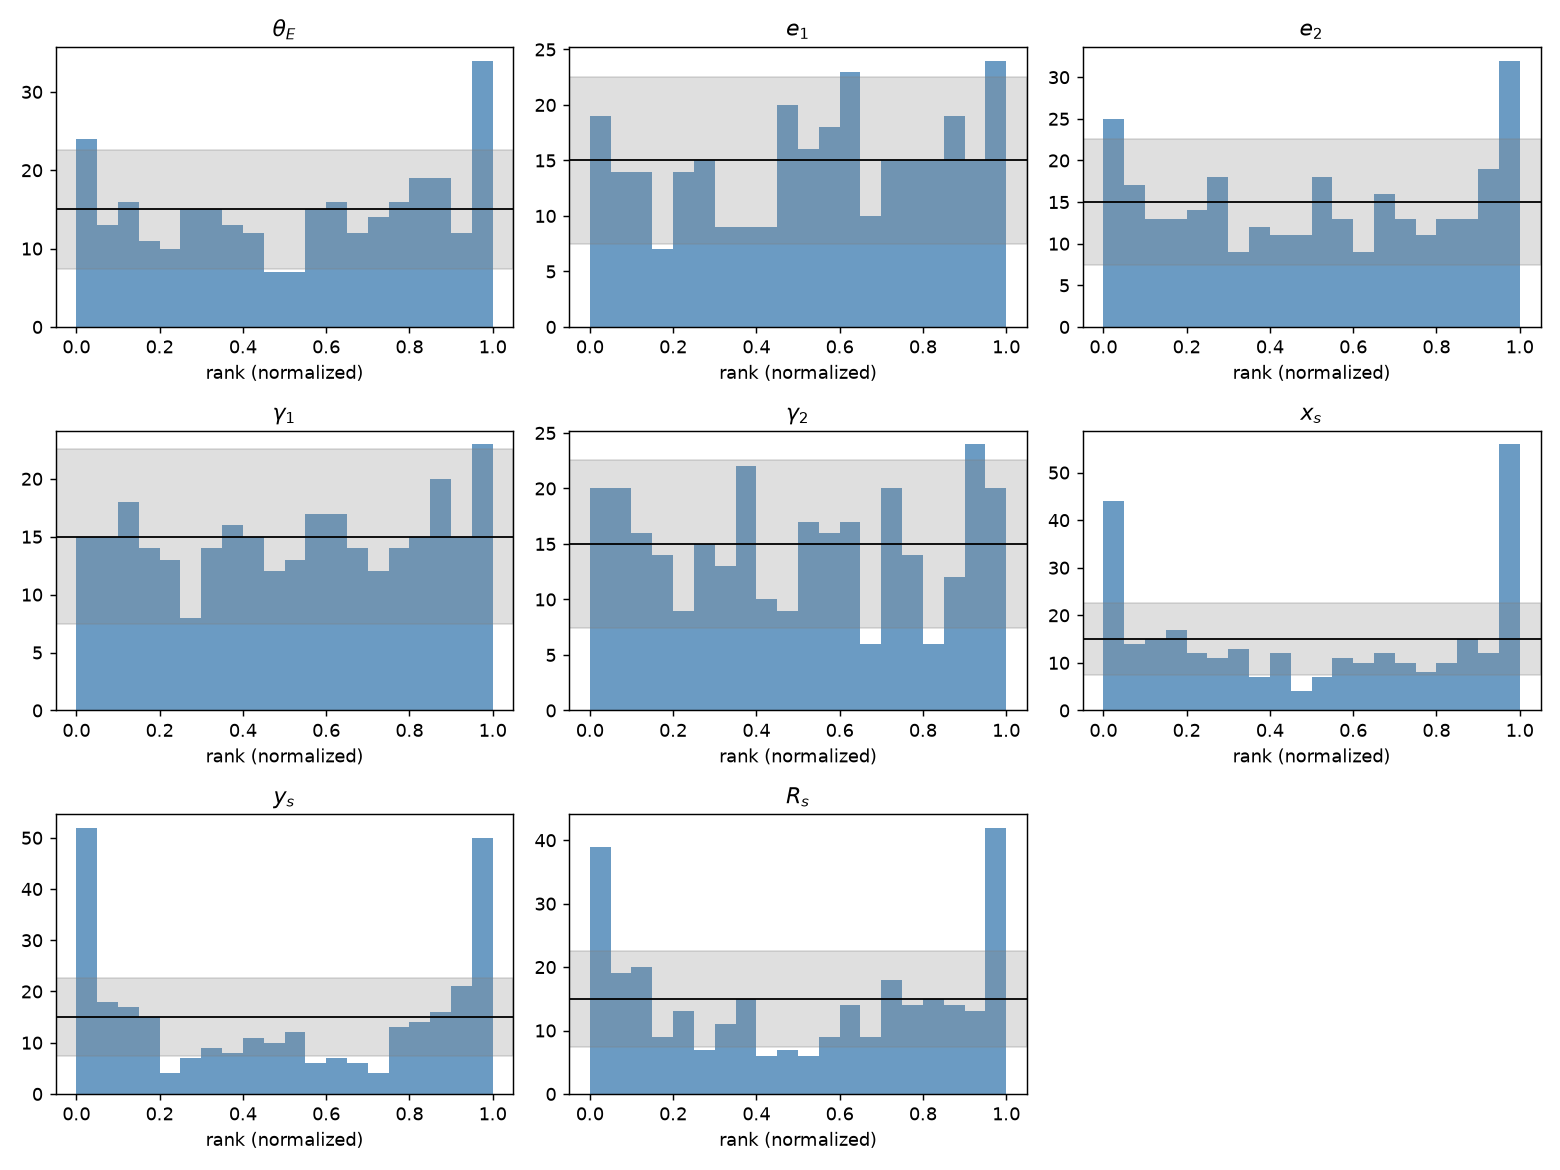

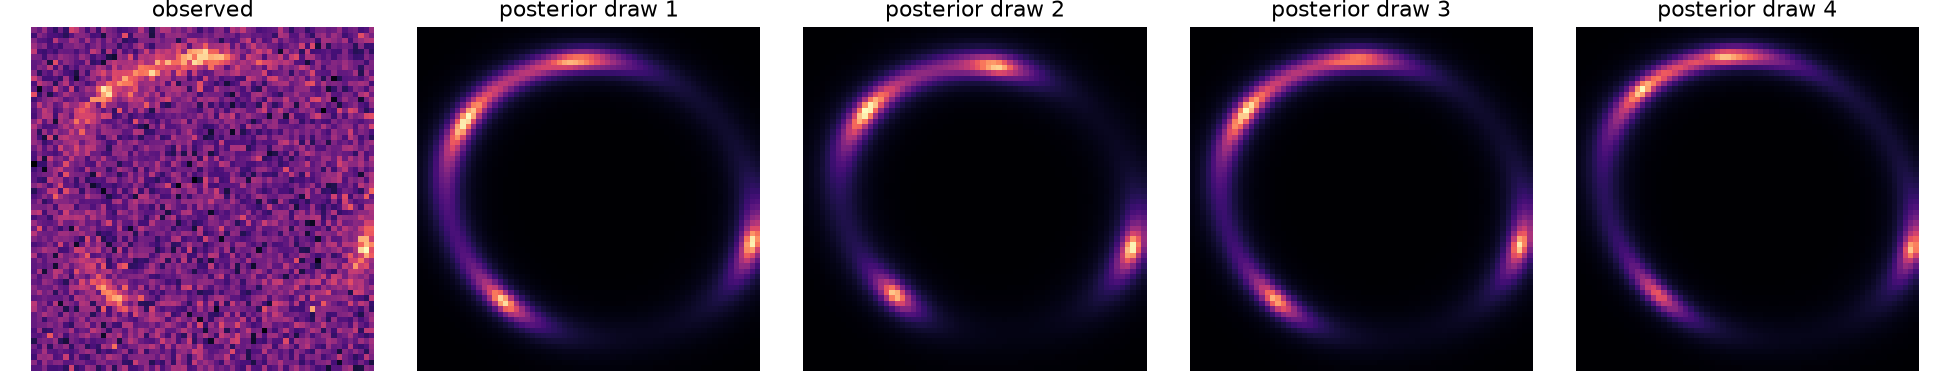

In [10]:
from IPython.display import Image, display

for fname in ["recovery.png", "calibration.png", "posterior_predictive.png"]:
    display(Image(filename=os.path.join("figures", fname)))

### 7b. One posterior in detail

Pick a single held-out system and look at the full 1-D marginal posterior for each
parameter, with the true (simulated) value marked -- a closer look than the summary
recovery plot above.

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 0.16 seconds.


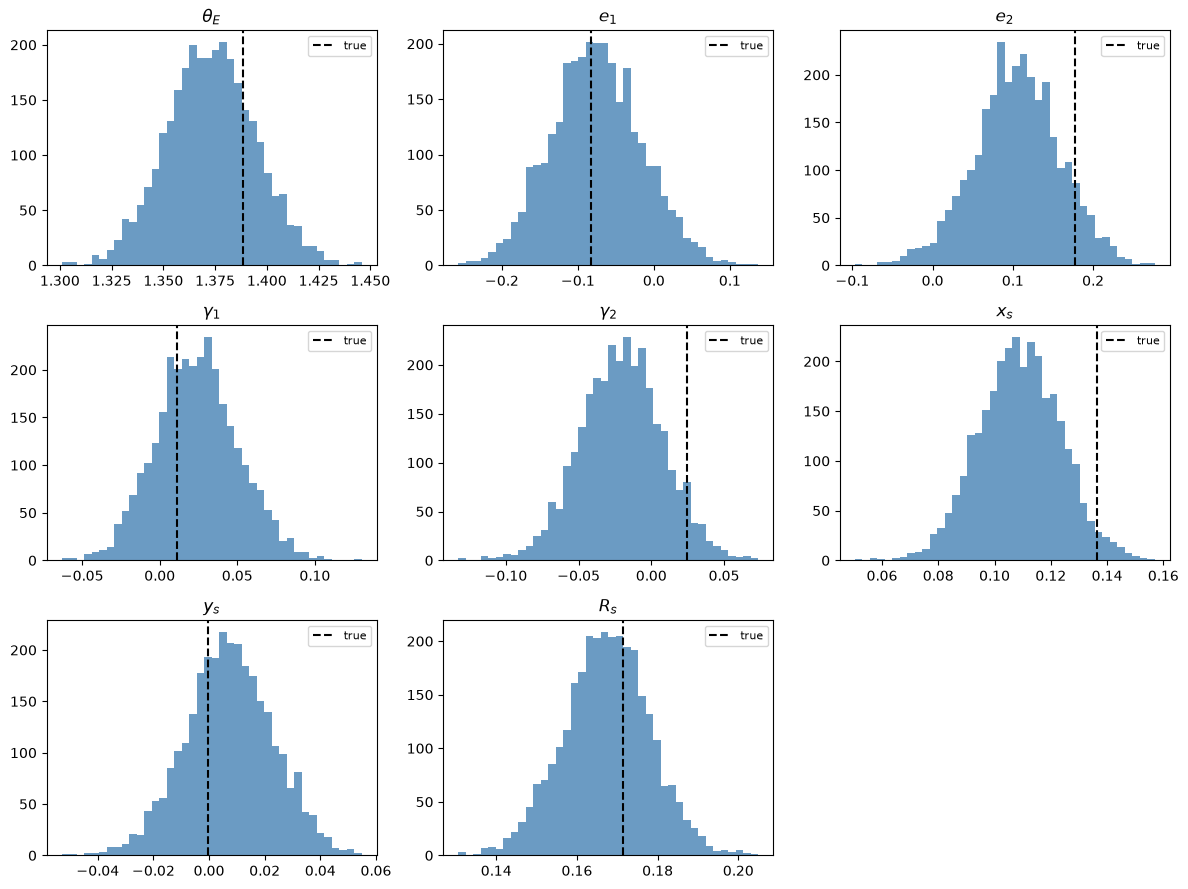

In [11]:
from src.evaluation.test import sample_posteriors

dtest = np.load(os.path.join(C.DATA_DIR, C.TEST_FILE))
theta_test, images_test = dtest["theta_test"], dtest["images_test"]

SYSTEM_IDX = 0  # try changing this to look at a different held-out lens
samples_one = sample_posteriors(workflow, images_test[SYSTEM_IDX:SYSTEM_IDX + 1], num_samples=3000)[0]

ncol = 3
nrow = int(np.ceil(C.NUM_PARAMS / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3 * nrow))
axes = np.array(axes).ravel()
for p, name in enumerate(C.PARAM_NAMES):
    axes[p].hist(samples_one[:, p], bins=40, color="steelblue", alpha=0.8)
    axes[p].axvline(theta_test[SYSTEM_IDX, p], color="k", ls="--", label="true")
    axes[p].set_title(C.PARAM_LABELS[name])
    axes[p].legend(fontsize=8)
for k in range(C.NUM_PARAMS, len(axes)):
    axes[k].axis("off")
fig.tight_layout(); plt.show()

## 8. The kappa (external convergence) comparison

The assignment asks: fix `kappa=0` (the simpler 8-parameter version) vs. infer it as a
9th parameter -- what differences do you observe? The expected answer is the **mass-sheet
degeneracy**: a uniform convergence sheet mostly rescales the *source*, not the observed
image morphology, so a single image barely constrains `kappa` on its own. We should see:
the `kappa` posterior stay almost as wide as its prior (little "contraction"), and a
strong correlation between `kappa` and `theta_E` within each posterior.

Rather than mutating `config.INCLUDE_KAPPA` inside this already-running kernel (which
would **not** safely update the derived `PARAM_NAMES`/`NUM_PARAMS` -- see the big
warning comment in `src/config.py`), we launch a fully independent `python main.py ...`
process with the `SLI_INCLUDE_KAPPA=1` environment variable set. `src/config.py` reads
that variable once, at import time, in the fresh process, so everything (array shapes,
dataset/model filenames) stays consistent automatically. This cell can take a while
(it repeats dataset generation + training for the 9-parameter version) -- shrink
`N_TRAIN`/`EPOCHS` first via the environment variables below if you just want to see the
mechanism work quickly.

In [12]:
import subprocess

kappa_env = dict(os.environ, SLI_INCLUDE_KAPPA="1")
for step in ["generate", "train", "evaluate"]:
    print(f"=== python main.py {step}  (SLI_INCLUDE_KAPPA=1) ===")
    result = subprocess.run([sys.executable, "main.py", step], cwd=PROJECT_ROOT,
                             env=kappa_env, capture_output=True, text=True)
    print(result.stdout[-3000:])
    if result.returncode != 0:
        print(result.stderr[-3000:])
        break

=== python main.py generate  (SLI_INCLUDE_KAPPA=1) ===
Generating TRAIN (8000) + VAL (1000) using 11 worker(s) ...
     500/8000  ( 56.6 sims/s, 11 workers)
    1000/8000  (112.4 sims/s, 11 workers)
    1500/8000  (166.2 sims/s, 11 workers)
    2000/8000  (217.5 sims/s, 11 workers)
    2500/8000  (268.5 sims/s, 11 workers)
    3000/8000  (316.1 sims/s, 11 workers)
    3500/8000  (363.2 sims/s, 11 workers)
    4000/8000  (409.9 sims/s, 11 workers)
    4500/8000  (452.9 sims/s, 11 workers)
    5000/8000  (496.6 sims/s, 11 workers)
    5500/8000  (538.6 sims/s, 11 workers)
    6000/8000  (579.3 sims/s, 11 workers)
    6500/8000  (618.6 sims/s, 11 workers)
    7000/8000  (656.1 sims/s, 11 workers)
    7500/8000  (694.5 sims/s, 11 workers)
    8000/8000  (733.5 sims/s, 11 workers)

  --- peak-SNR report (tune config.SOURCE_AMP / BACKGROUND_RMS) ---
    min=  0.6  median=  3.9  max=  7.7   target ~ 10-30

     500/1000  ( 56.8 sims/s, 11 workers)
    1000/1000  (112.2 sims/s, 11 workers)
Sav

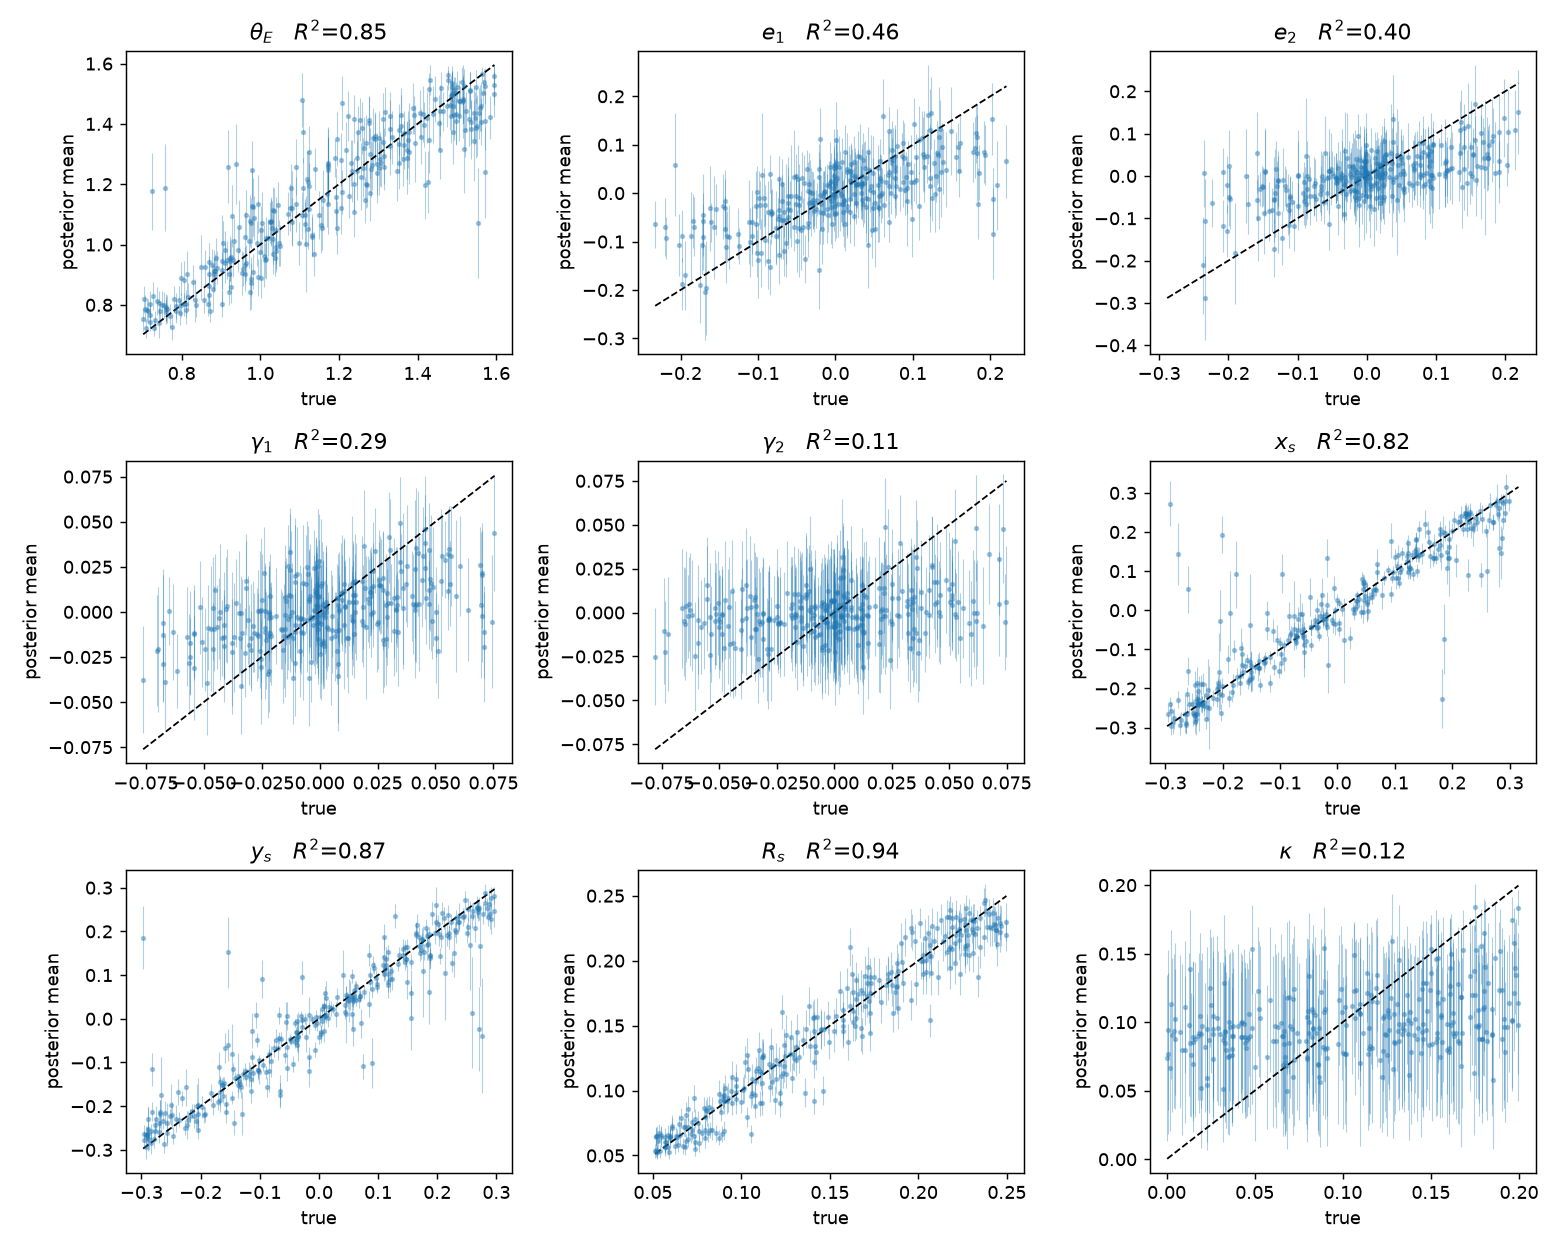

In [ ]:
# The with-kappa run wrote its own figures/*.png -- same filenames, so they
# overwrote the 8-parameter ones from Section 7. That's fine: the printed
# "kappa (external convergence) / mass-sheet degeneracy" block above already
# has the key numbers (posterior-std contraction and kappa-theta_E correlation).
# Re-display the fresh recovery plot -- compare theta_E's scatter/R^2 here
# against Section 7's: the assignment's own note is that dropping kappa usually
# tightens the other parameters slightly....
display(Image(filename=os.path.join("figures", "recovery.png")))

## 9. Cheat-sheet: what can I change, where, and what happens?

Every row below is a value in **`src/config.py`** unless noted otherwise. After changing
one, re-run from Section 4 onward (dataset -> train -> evaluate) to see the effect; a
restart of the kernel is only required for `INCLUDE_KAPPA` (see Section 8).

| Parameter | What it controls | What happens if you change it |
|---|---|---|
| `BACKGROUND_RMS`, `EXP_TIME`, `SOURCE_AMP` | Noise level / SNR of simulated images | More noise (higher `BACKGROUND_RMS`, lower `EXP_TIME` or `SOURCE_AMP`) -> lower SNR -> wider, less certain posteriors after retraining. Use Section 3's SNR histogram to keep it near 10-30. |
| `NUM_PIX`, `DELTA_PIX` | Image resolution / field of view | Bigger images are sharper but slower to simulate *and* slower for the CNN -- noticeable on CPU. |
| `PSF_FWHM` | How blurry the fixed point-spread function is | A bigger PSF smears out fine structure (e.g. arc thickness), making `R_s` harder to recover. |
| `PRIOR` dict | The range of physically plausible lenses simulated | Narrower ranges make the task easier (better-looking recovery plots, but for an easier problem); wider ranges are more realistic but need more data/epochs to fit as well. |
| `INCLUDE_KAPPA` | 8-parameter vs. 9-parameter (with external convergence) model | See Section 8: this is the mass-sheet-degeneracy comparison the assignment asks for. Change via the `SLI_INCLUDE_KAPPA=1` environment variable (or edit the file + restart kernel), not by mutating the imported module. |
| `N_TRAIN`, `N_VAL`, `N_TEST` | Dataset sizes | More training data generally improves posterior accuracy and calibration, at the direct cost of longer `generate` and `train` steps. Start small (1500-3000) to iterate quickly, scale up for your final results. |
| `N_WORKERS` | CPU processes used during `generate` | Higher = faster dataset generation, up to your core count; set to 1 if you need the machine responsive for other work, or if you hit RAM pressure running many worker processes at once. |
| `SUMMARY_DIM`, `COUPLING_DEPTH` | Neural network capacity | Bigger networks can represent more complex posteriors but train slower and can overfit if `N_TRAIN` is small. |
| `EPOCHS`, `BATCH_SIZE`, `LEARNING_RATE` | Training | If Section 6's loss curve is still clearly decreasing at the last epoch, increase `EPOCHS` first -- it's the cheapest knob. Larger `BATCH_SIZE` needs more RAM per step but fewer steps per epoch. |
| `KERAS_BACKEND` | Which framework runs the networks | Default `torch` (CPU) needs no extra install and matches this project's `requirements.txt`. If you separately install a CPU build of `jax`, set this to `jax` for typically faster training -- nothing else changes. |

**If your machine struggles (very little RAM, very few CPU cores):** lower `N_TRAIN`,
`BATCH_SIZE`, `SUMMARY_DIM`, and `COUPLING_DEPTH` together, and set `N_WORKERS=1`. The
pipeline will still run, just with a less sharp posterior -- appropriate to say so
explicitly if you report results from a shrunk configuration.